In [1]:
import torch
from transformers import GPT2Model, GPT2Tokenizer
from transformers import BertModel, BertTokenizer
import matplotlib.pyplot as plt
import numpy as np
from torch.nn.functional import cosine_similarity

# GPT2
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2Model.from_pretrained("gpt2")
gpt2_model.eval()

# BERT
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()

print("GPT2 aur BERT dono ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6248.02it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can

GPT2 aur BERT dono ready!


In [2]:
words = ["king", "queen", "man", "woman", 
         "dog", "cat", "car", "truck", "happy", "sad"]

def get_gpt2_embedding(word):
    inputs = gpt2_tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = gpt2_model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0)

def get_bert_embedding(word):
    inputs = bert_tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0)


gpt2_embeddings = torch.stack([get_gpt2_embedding(w) for w in words])
bert_embeddings = torch.stack([get_bert_embedding(w) for w in words])

print(f"Words: {words}")
print(f"GPT2 embeddings shape: {gpt2_embeddings.shape}")
print(f"BERT embeddings shape: {bert_embeddings.shape}")

Words: ['king', 'queen', 'man', 'woman', 'dog', 'cat', 'car', 'truck', 'happy', 'sad']
GPT2 embeddings shape: torch.Size([10, 768])
BERT embeddings shape: torch.Size([10, 768])


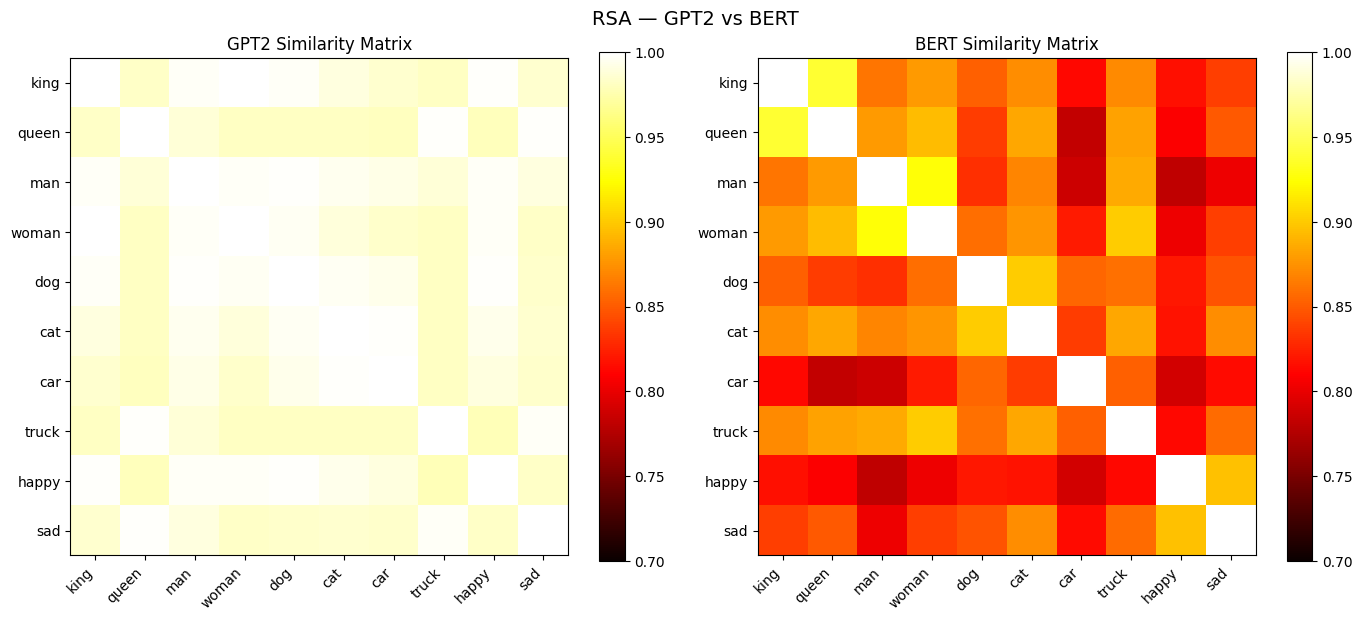

In [3]:
# Dono models ki similarity matrices
n = len(words)
gpt2_sim = torch.zeros(n, n)
bert_sim  = torch.zeros(n, n)

for i in range(n):
    for j in range(n):
        gpt2_sim[i, j] = cosine_similarity(
            gpt2_embeddings[i].unsqueeze(0),
            gpt2_embeddings[j].unsqueeze(0)
        ).item()
        bert_sim[i, j] = cosine_similarity(
            bert_embeddings[i].unsqueeze(0),
            bert_embeddings[j].unsqueeze(0)
        ).item()

# Dono matrices visualize karo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sim, title in zip(axes, 
                           [gpt2_sim, bert_sim], 
                           ["GPT2", "BERT"]):
    im = ax.imshow(sim.numpy(), cmap="hot", vmin=0.7, vmax=1.0)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(words, rotation=45, ha="right")
    ax.set_yticklabels(words)
    ax.set_title(f"{title} Similarity Matrix")
    plt.colorbar(im, ax=ax)

plt.suptitle("RSA — GPT2 vs BERT", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

gpt2_flat = gpt2_sim.numpy().flatten()
bert_flat  = bert_sim.numpy().flatten()

correlation = np.corrcoef(gpt2_flat, bert_flat)[0, 1]
print(f"GPT2 vs BERT RSA correlation: {correlation:.4f}")

GPT2 vs BERT RSA correlation: 0.3127


* GPT-2 and BERT have **very different similarity structures**.

* The correlation is only **0.31**, which indicates that their **internal representations are quite different**.

* BERT is better at **differentiating words based on meaning (contextual understanding)**.

* GPT-2 tends to treat many words as **more uniformly similar**, showing less sharp separation compared to BERT.
